# Mutual Fund Analytics Platform

## Objective
Briefly explain the purpose of the notebook `02_data_cleaning.ipynb`.

## Author
Bhawani Meena

## Tools Used
List the major libraries used in this notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

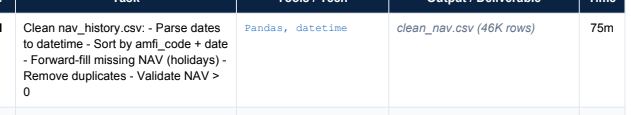

## Data Loading

In [ ]:
nav = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/raw/02_nav_history.csv")
print(nav.shape)

(46000, 3)


In [ ]:
print(nav.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None


In [ ]:
print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


## Data Cleaning

In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)
print(nav)

       amfi_code       date       nav
5750      100016 2022-01-03  520.4608
5751      100016 2022-01-04  515.0971
5752      100016 2022-01-05  521.7239
5753      100016 2022-01-06  515.7880
5754      100016 2022-01-07  515.1639
...          ...        ...       ...
45995     149324 2026-05-25  292.4810
45996     149324 2026-05-26  291.2707
45997     149324 2026-05-27  288.8007
45998     149324 2026-05-28  280.6873
45999     149324 2026-05-29  279.7511

[46000 rows x 3 columns]


In [ ]:
print(nav.isnull().sum())
print(nav.duplicated().sum())

amfi_code    0
date         0
nav          0
dtype: int64
0


In [ ]:
(nav["nav"] <= 0).sum()

np.int64(0)

In [ ]:
nav.to_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv")

## Data Loading

In [ ]:
tx = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/08_investor_transactions.csv"
)

print(tx.columns)
print(tx.head())
print(tx.info())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra  

In [ ]:
tx.isnull().sum()

,0
investor_id,0
transaction_date,0
amfi_code,0
transaction_type,0
amount_inr,0
state,0
city,0
city_tier,0
age_group,0
gender,0


## Exploratory Data Analysis

In [ ]:
tx["transaction_type"].value_counts()

,count
transaction_type,
SIP,19716
Lumpsum,8095
Redemption,4967


 type of transaction_date is object, but it should be converted into int

## Data Cleaning

In [ ]:
tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

In [ ]:
print(tx["transaction_date"].dtypes)

datetime64[ns]


In [ ]:
tx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), ob

In [ ]:
(tx["amount_inr"] <= 0).sum()

np.int64(0)

## Exploratory Data Analysis

In [ ]:
tx["kyc_status"].value_counts()

,count
kyc_status,
Verified,30146
Pending,2632


In [ ]:
tx.duplicated().sum()

np.int64(0)

In [ ]:
tx.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv",
    index=False
)

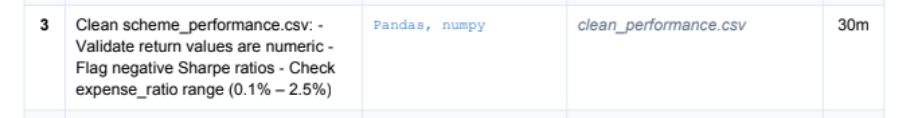

## Data Loading

In [ ]:
per = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/raw/07_scheme_performance.csv")
print(per.shape)
print(per.info())

(40, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  e

In [ ]:
per.duplicated().sum()

np.int64(0)

if sharp ratio will be negative then what do I do?
the negative sharpe ration is responsible for poor return than risk free rate.

## Performance Analysis

In [ ]:
(per['sharpe_ratio']<0).sum()

np.int64(0)

check expensive ratio from range 0.1 to 2.5

In [ ]:
((per["expense_ratio_pct"] < 0.1) | (per["expense_ratio_pct"] > 2.5)).sum()

np.int64(0)

In [ ]:
per.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_performance.csv",
    index=False
)

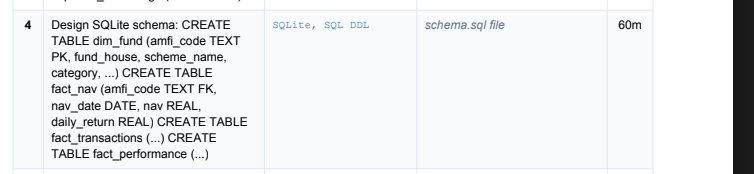

In [ ]:
import sqlite3

db_path = "/content/drive/MyDrive/bluestock_mf_capstone/data/db/bluestock_mf.db"

conn = sqlite3.connect(db_path)

print("Database created successfully!")

Database created successfully!


## Data Loading

In [ ]:
fund = pd.read_csv("/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv")
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## Data Cleaning

In [ ]:
fund.to_sql( "dim_fund", conn, if_exists='replace', index=False)

40

In [ ]:
nav.to_sql(
    "fact_nav",
    conn,
    if_exists="replace",
    index=False
)

46000

In [ ]:
tx.to_sql(
    "fact_transactions",
    conn,
    if_exists="replace",
    index=False
)

32778

In [ ]:
per.to_sql(
    "fact_performance",
    conn,
    if_exists="replace",
    index=False
)

40

In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance


In [ ]:
pd.read_sql("""
SELECT COUNT(*) as total_funds
FROM dim_fund
""", conn)

,total_funds
0,40


In [ ]:
pd.read_sql("""
SELECT COUNT(*) as total_nav_records
FROM fact_nav
""", conn)

,total_nav_records
0,46000


In [ ]:
pd.read_sql("""
SELECT COUNT(*) as total_transactions
FROM fact_transactions
""", conn)

,total_transactions
0,32778


In [ ]:
queries = """
-- Count total funds
SELECT COUNT(*) FROM dim_fund;

-- Count total NAV records
SELECT COUNT(*) FROM fact_nav;

-- Top 5 fund houses
SELECT fund_house, COUNT(*)
FROM dim_fund
GROUP BY fund_house;
"""

path = "/content/drive/MyDrive/bluestock_mf_capstone/sql/queries.sql"

with open(path, "w") as f:
    f.write(queries)

print("queries.sql saved successfully!")

queries.sql saved successfully!


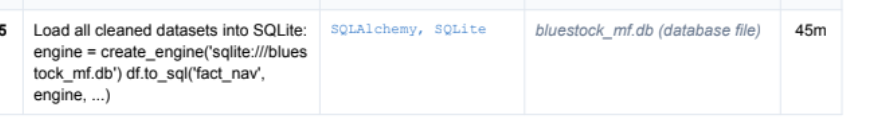

In [ ]:
import sqlite3

db_path = "/content/drive/MyDrive/bluestock_mf_capstone/data/db/bluestock_mf.db"

conn = sqlite3.connect(db_path)

print("Database connected!")

Database connected!


## Data Loading

In [ ]:
import pandas as pd

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

fund.to_sql(
    "dim_fund",
    conn,
    if_exists="replace",
    index=False
)

print("dim_fund loaded")

dim_fund loaded


In [ ]:
nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav.to_sql(
    "fact_nav",
    conn,
    if_exists="replace",
    index=False
)

print("fact_nav loaded")

fact_nav loaded


In [ ]:
tx = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv"
)

tx.to_sql(
    "fact_transactions",
    conn,
    if_exists="replace",
    index=False
)

print("fact_transactions loaded")

fact_transactions loaded


In [ ]:
perf = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_performance.csv"
)

perf.to_sql(
    "fact_performance",
    conn,
    if_exists="replace",
    index=False
)

print("fact_performance loaded")

fact_performance loaded


In [ ]:
aum = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/03_aum_by_fund_house.csv"
)

aum.to_sql(
    "fact_aum",
    conn,
    if_exists="replace",
    index=False
)

print("fact_aum loaded")

fact_aum loaded


In [ ]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance
4,fact_aum


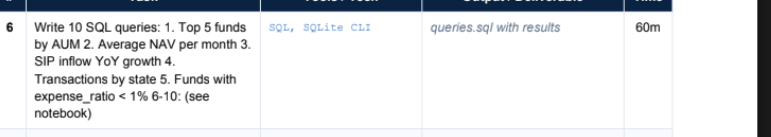

Query:1 Top 5 funds by AUM

In [ ]:
pd.read_sql("""
SELECT fund_house,
       MAX(aum_crore) AS max_aum
FROM fact_aum
GROUP BY fund_house
ORDER BY max_aum DESC
LIMIT 5
""", conn)

,fund_house,max_aum
0,SBI Mutual Fund,1250000
1,ICICI Prudential MF,1074000
2,HDFC Mutual Fund,930000
3,Nippon India MF,700000
4,Kotak Mahindra MF,580000


Query 2: Average NAV Per Scheme

In [ ]:
pd.read_sql("""
SELECT amfi_code,
       ROUND(AVG(nav),2) AS avg_nav
FROM fact_nav
GROUP BY amfi_code
ORDER BY avg_nav DESC
LIMIT 10
""", conn)

,amfi_code,avg_nav
0,120844,3705.88
1,125497,797.45
2,100016,566.19
3,149322,439.18
4,101206,435.98
5,101208,358.39
6,120841,355.08
7,120507,334.08
8,120505,284.00
9,120506,274.32


Query 3: Transactions by State

In [ ]:
pd.read_sql("""
SELECT state,
       COUNT(*) AS total_transactions
FROM fact_transactions
GROUP BY state
ORDER BY total_transactions DESC
""", conn)

,state,total_transactions
0,Punjab,2965
1,Madhya Pradesh,2931
2,Tamil Nadu,2806
3,Gujarat,2780
4,West Bengal,2748
5,Haryana,2736
6,Telangana,2718
7,Uttar Pradesh,2695
8,Delhi,2677
9,Karnataka,2621


Query 4: Total Investment by State

In [ ]:
pd.read_sql("""
SELECT state,
       ROUND(SUM(amount_inr),2) AS total_amount
FROM fact_transactions
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10
""", conn)

,state,total_amount
0,Punjab,315780459.0
1,Tamil Nadu,315177237.0
2,Madhya Pradesh,308312493.0
3,Rajasthan,298645822.0
4,Gujarat,298358940.0
5,West Bengal,297182514.0
6,Telangana,290219284.0
7,Delhi,289633404.0
8,Uttar Pradesh,285368873.0
9,Haryana,279634354.0


Query 5: Funds with Expense Ratio < 1%

In [ ]:
pd.read_sql("""
SELECT scheme_name,
       expense_ratio_pct
FROM dim_fund
WHERE expense_ratio_pct < 1
ORDER BY expense_ratio_pct
""", conn)

,scheme_name,expense_ratio_pct
0,Nippon India Gilt Securities Fund - Regular - ...,0.55
1,HDFC Short Term Debt Fund - Regular - Growth,0.56
2,Kotak Liquid Fund - Regular - Growth,0.60
3,SBI Bluechip Fund - Direct Plan - Growth,0.66
4,SBI Small Cap Fund - Direct Plan - Growth,0.72
5,Nippon India Large Cap Fund - Direct - Growth,0.72
6,ICICI Pru Liquid Fund - Regular - Growth,0.74
7,Axis Bluechip Fund - Direct - Growth,0.75
8,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77
9,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.78


Query 6: Number of Funds by Category

In [ ]:
pd.read_sql("""
SELECT category,
       COUNT(*) AS total_funds
FROM dim_fund
GROUP BY category
""", conn)

,category,total_funds
0,Debt,6
1,Equity,34


Query 7: KYC Status Distribution

In [ ]:
pd.read_sql("""
SELECT kyc_status,
       COUNT(*) AS investors
FROM fact_transactions
GROUP BY kyc_status
""", conn)

,kyc_status,investors
0,Pending,2632
1,Verified,30146


Query 8: Transaction Type Distribution

In [ ]:
pd.read_sql("""
SELECT transaction_type,
       COUNT(*) AS count
FROM fact_transactions
GROUP BY transaction_type
""", conn)

,transaction_type,count
0,Lumpsum,8095
1,Redemption,4967
2,SIP,19716


Query 9: Gender-wise Investment

In [ ]:
pd.read_sql("""
SELECT gender,
       ROUND(SUM(amount_inr),2) AS total_amount
FROM fact_transactions
GROUP BY gender
""", conn)

,gender,total_amount
0,Female,1.176347e+09
1,Male,2.345234e+09


Query 10: Top 10 Performing Funds

In [ ]:
pd.read_sql("""
SELECT scheme_name,
       return_1yr_pct
FROM fact_performance
ORDER BY return_1yr_pct DESC
LIMIT 10
""", conn)

,scheme_name,return_1yr_pct
0,ABSL Small Cap Fund - Regular - Growth,24.93
1,SBI Small Cap Fund - Regular Plan - Growth,24.56
2,Axis Small Cap Fund - Regular - Growth,21.97
3,Nippon India Small Cap Fund - Regular - Growth,21.30
4,SBI Small Cap Fund - Direct Plan - Growth,20.59
5,DSP Small Cap Fund - Regular - Growth,20.20
6,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98
7,UTI Flexi Cap Fund - Regular - Growth,17.43
8,Kotak Emerging Equity Fund - Regular - Growth,17.12
9,ICICI Pru Value Discovery Fund - Regular - Growth,16.67


In [ ]:
queries = """
-- Query 1: Top 5 Fund Houses by AUM
SELECT fund_house,
       MAX(aum_crore) AS max_aum
FROM fact_aum
GROUP BY fund_house
ORDER BY max_aum DESC
LIMIT 5;

-- Query 2: Average NAV Per Scheme
SELECT amfi_code,
       ROUND(AVG(nav),2) AS avg_nav
FROM fact_nav
GROUP BY amfi_code
ORDER BY avg_nav DESC
LIMIT 10;

-- Query 3: Transactions by State
SELECT state,
       COUNT(*) AS total_transactions
FROM fact_transactions
GROUP BY state
ORDER BY total_transactions DESC;

-- Query 4: Total Investment by State
SELECT state,
       ROUND(SUM(amount_inr),2) AS total_amount
FROM fact_transactions
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10;

-- Query 5: Funds with Expense Ratio < 1%
SELECT scheme_name,
       expense_ratio_pct
FROM dim_fund
WHERE expense_ratio_pct < 1
ORDER BY expense_ratio_pct;

-- Query 6: Number of Funds by Category
SELECT category,
       COUNT(*) AS total_funds
FROM dim_fund
GROUP BY category;

-- Query 7: KYC Status Distribution
SELECT kyc_status,
       COUNT(*) AS investors
FROM fact_transactions
GROUP BY kyc_status;

-- Query 8: Transaction Type Distribution
SELECT transaction_type,
       COUNT(*) AS count
FROM fact_transactions
GROUP BY transaction_type;

-- Query 9: Gender-wise Investment
SELECT gender,
       ROUND(SUM(amount_inr),2) AS total_amount
FROM fact_transactions
GROUP BY gender;

-- Query 10: Top 10 Funds by Average NAV
SELECT amfi_code,
       ROUND(AVG(nav),2) AS avg_nav
FROM fact_nav
GROUP BY amfi_code
ORDER BY avg_nav DESC
LIMIT 10;
"""

path = "/content/drive/MyDrive/bluestock_mf_capstone/sql/queries.sql"

with open(path, "w") as f:
    f.write(queries)

print("queries.sql created successfully!")

queries.sql created successfully!


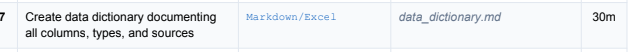

## Performance Analysis

In [ ]:
data_dictionary = """
# Mutual Fund Analytics Capstone - Data Dictionary

## 1. dim_fund (01_fund_master.csv)

| Column Name | Data Type | Description |
|------------|-----------|-------------|
| amfi_code | Integer | Unique AMFI scheme code |
| fund_house | Text | Mutual fund company name |
| scheme_name | Text | Mutual fund scheme name |
| category | Text | Fund category (Equity, Debt, Hybrid) |
| sub_category | Text | Fund sub-category |
| plan | Text | Direct or Regular plan |
| launch_date | Date | Scheme launch date |
| benchmark | Text | Benchmark index |
| expense_ratio_pct | Float | Expense ratio percentage |
| exit_load_pct | Float | Exit load percentage |
| min_sip_amount | Integer | Minimum SIP investment amount |
| min_lumpsum_amount | Integer | Minimum lump sum investment |
| fund_manager | Text | Fund manager name |
| risk_category | Text | Risk level of fund |
| sebi_category_code | Text | SEBI category code |

---

## 2. fact_nav (clean_nav.csv)

| Column Name | Data Type | Description |
|------------|-----------|-------------|
| amfi_code | Integer | Mutual fund scheme code |
| date | Date | NAV date |
| nav | Float | Net Asset Value |

---

## 3. fact_transactions (clean_transactions.csv)

| Column Name | Data Type | Description |
|------------|-----------|-------------|
| investor_id | Text | Unique investor identifier |
| transaction_date | Date | Transaction date |
| amfi_code | Integer | Mutual fund scheme code |
| transaction_type | Text | SIP, Lumpsum or Redemption |
| amount_inr | Float | Transaction amount in INR |
| state | Text | Investor state |
| city | Text | Investor city |
| city_tier | Text | T30 or B30 city classification |
| age_group | Text | Investor age group |
| gender | Text | Investor gender |
| annual_income_lakh | Float | Annual income in lakhs |
| payment_mode | Text | Mode of payment |
| kyc_status | Text | KYC verification status |

---

## 4. fact_performance (clean_performance.csv)

| Column Name | Data Type | Description |
|------------|-----------|-------------|
| amfi_code | Integer | Mutual fund scheme code |
| return_1yr | Float | One-year return (%) |
| return_3yr | Float | Three-year return (%) |
| return_5yr | Float | Five-year return (%) |
| sharpe_ratio | Float | Sharpe ratio |
| sortino_ratio | Float | Sortino ratio |
| alpha | Float | Alpha value |
| beta | Float | Beta value |
| max_drawdown | Float | Maximum drawdown |
| std_dev | Float | Standard deviation |

---

## 5. fact_aum (03_aum_by_fund_house.csv)

| Column Name | Data Type | Description |
|------------|-----------|-------------|
| fund_house | Text | Mutual fund company |
| date | Date | Reporting date |
| aum_crore | Float | Assets Under Management (crore INR) |

---

## Database Tables

1. dim_fund
2. fact_nav
3. fact_transactions
4. fact_performance
5. fact_aum

Prepared for Bluestock Mutual Fund Analytics Capstone Project.
"""

path = "/content/drive/MyDrive/bluestock_mf_capstone/data_dictionary.md"

with open(path, "w", encoding="utf-8") as f:
    f.write(data_dictionary)

print(" data_dictionary.md created successfully!")
print(" Saved at:", path)

 data_dictionary.md created successfully!
 Saved at: /content/drive/MyDrive/bluestock_mf_capstone/data_dictionary.md


In [2]:
readme_content = """
# Mutual Fund Analytics Platform

## Project Overview

The Mutual Fund Analytics Platform is an end-to-end data analytics project designed to analyze mutual fund performance, investor behavior, portfolio risk, and industry trends. The project combines data engineering, exploratory data analysis, financial analytics, and business intelligence techniques using Python, SQLite, and Power BI.

The platform provides insights into:

* Mutual fund performance evaluation
* Risk and return analysis
* Investor demographics and transaction behavior
* SIP growth and market trends
* Portfolio diversification and concentration risk
* Fund recommendation systems

---

## Project Structure

```text
bluestock_mf_capstone/

├── dashboard/
│   ├── page1.png
│   ├── page2.png
│   ├── page3.png
│   ├── page4.png
│   └── README.md
│
├── data/
│   ├── raw/
│   ├── processed/
│   └── db/
│
├── notebooks_cleaned/
│   ├── CLEANED_01_data_ingestion.ipynb
│   ├── CLEANED_02_data_cleaning.ipynb
│   ├── CLEANED_03_eda.ipynb
│   ├── CLEANED_04_performance_analysis.ipynb
│   └── CLEANED_05_advanced_analytics.ipynb
│
├── reports/
│   ├── Final_Report.pdf
│   └── charts/
│
├── scripts/
│   ├── etl_pipeline.py
│   ├── compute_metrics.py
│   ├── recommender.py
│   └── run_pipeline.py
│
├── sql/
│   ├── schema.sql
│   └── queries.sql
│
├── data_dictionary.md
└── README.md
```

---

## Datasets Used

The project uses the following datasets:

* Fund Master Data
* NAV History Data
* Portfolio Holdings Data
* Investor Transactions Data
* SIP Inflow Data
* Benchmark Index Data

---

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* SQLite
* Power BI
* Git & GitHub

---

## Setup Instructions

### 1. Clone Repository

```bash
git clone <repository-url>
cd bluestock_mf_capstone
```

### 2. Install Dependencies

```bash
pip install pandas numpy matplotlib seaborn scipy jupyter
```

### 3. Open Jupyter Notebook

```bash
jupyter notebook
```

---

## How to Run ETL

Open and execute:

```text
notebooks_cleaned/CLEANED_01_data_ingestion.ipynb
notebooks_cleaned/CLEANED_02_data_cleaning.ipynb
```

These notebooks perform:

* Data ingestion
* Data validation
* Missing value handling
* Data cleaning
* Feature engineering
* Processed dataset generation

---

## How to Run Analytics

Execute notebooks in the following order:

1. CLEANED_01_data_ingestion.ipynb
2. CLEANED_02_data_cleaning.ipynb
3. CLEANED_03_eda.ipynb
4. CLEANED_04_performance_analysis.ipynb
5. CLEANED_05_advanced_analytics.ipynb

---

## Key Analytics Performed

### Performance Analytics

* Daily Returns
* Annualized Returns
* CAGR
* Sharpe Ratio
* Sortino Ratio
* Alpha
* Beta
* Maximum Drawdown

### Risk Analytics

* Value at Risk (VaR)
* Conditional VaR (CVaR)
* Rolling Sharpe Ratio
* Sector Concentration (HHI)

### Investor Analytics

* Cohort Analysis
* SIP Continuity Analysis
* State-wise Transaction Analysis
* Age Group Analysis

### Recommendation System

* Risk-based Mutual Fund Recommendation Engine

---

## Dashboard

To view the dashboard:

1. Open Microsoft Power BI Desktop.
2. Open the dashboard file:

```text
dashboard/Mutual_Fund_Dashboard.pbix
```

Dashboard Pages:

* Industry Overview
* Fund Performance
* Investor Analytics
* SIP & Market Trends

---

## Deliverables

* Final_Report.pdf
* Power BI Dashboard
* Processed Datasets
* Analytical Reports
* Python Scripts
* SQL Database and Queries

---

## Author

**Bhawani Meena**
IIT Delhi
Mutual Fund Analytics Capstone Project
"""

path = "/content/drive/MyDrive/bluestock_mf_capstone/README.md"

with open(path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")
print("Saved at:", path)

README.md created successfully!
Saved at: /content/drive/MyDrive/bluestock_mf_capstone/README.md


## Key Findings
Summarize the important results generated in this notebook.
